In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mojtaba142/hotel-booking")

print("Path to dataset files:", path)

100%|██████████| 4.40M/4.40M [00:00<00:00, 22.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mojtaba142/hotel-booking/versions/1


In [ ]:
import os
import pandas as pd

# List files to find the CSV
files = os.listdir(path)
print(f"Files found: {files}")

# Find the first CSV file in the directory
csv_file = next((f for f in files if f.endswith('.csv')), None)

if csv_file:
    csv_path = os.path.join(path, csv_file)
    print(f"Loading data from: {csv_path}")

    # Load the dataset
    hotels = pd.read_csv(csv_path)
    display(hotels.head())
else:
    print("No CSV file found in the dataset directory.")

Files found: ['hotel_booking.csv']
Loading data from: /root/.cache/kagglehub/datasets/mojtaba142/hotel-booking/versions/1/hotel_booking.csv


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [ ]:
# 1. Empty Values (Missing Data)
missing_values = hotels.isnull().sum()

# Filter to show only columns with missing values and calculate percentage
missing_data = missing_values[missing_values > 0]
if not missing_data.empty:
    missing_df = pd.DataFrame({
        'Missing Count': missing_data,
        'Percentage': (missing_data / len(hotels)) * 100
    }).sort_values(by='Percentage', ascending=False)
    print("Columns with Missing Values:")
    display(missing_df)
else:
    print("No missing values found in the dataset.")

Columns with Missing Values:


,Missing Count,Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


In [ ]:
# 2. Data Types
print("Data Types and Info:")
hotels.info()

Data Types and Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  


In [ ]:
# 3. Descriptive Statistics
print("Descriptive Statistics (Numerical):")
display(hotels.describe())

print("\nDescriptive Statistics (Categorical):")
display(hotels.describe(include='object'))

Descriptive Statistics (Numerical):


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000



Descriptive Statistics (Categorical):


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date,name,email,phone-number,credit_card
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926,81503,115889,119390,9000
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21,Michael Johnson,Michael.C@gmail.com,422-804-6403,************3627
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461,48,6,1,28


In [ ]:
pd.set_option('display.max_columns', None)
display(hotels.head(5))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [ ]:
# Display unique values for each column
for col in hotels.columns:
    unique_vals = hotels[col].unique()
    num_unique = len(unique_vals)

    print(f"Column: {col}")
    print(f"Number of unique values: {num_unique}")

    if num_unique < 50:
        print(f"Values: {unique_vals}")
    else:
        print(f"Top 10 most frequent values: {hotels[col].value_counts().head(10).index.tolist()}")
    print("-" * 30)

Column: hotel
Number of unique values: 2
Values: ['Resort Hotel' 'City Hotel']
------------------------------
Column: is_canceled
Number of unique values: 2
Values: [0 1]
------------------------------
Column: lead_time
Number of unique values: 479
Top 10 most frequent values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 12]
------------------------------
Column: arrival_date_year
Number of unique values: 3
Values: [2015 2016 2017]
------------------------------
Column: arrival_date_month
Number of unique values: 12
Values: ['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
------------------------------
Column: arrival_date_week_number
Number of unique values: 53
Top 10 most frequent values: [33, 30, 32, 34, 18, 21, 28, 17, 20, 29]
------------------------------
Column: arrival_date_day_of_month
Number of unique values: 31
Values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
---------------

## Keeping Relevant Data only

In [ ]:
# Define the list of columns to keep
# Note: corrected 'is_cancelled' to 'is_canceled'
selected_columns = [
    'hotel', 'is_canceled', 'lead_time', 'arrival_date_month',
    'stays_in_weekend_nights', 'adults', 'children', 'babies',
    'meal', 'market_segment', 'is_repeated_guest', 'previous_cancellations',
    'previous_bookings_not_canceled', 'reserved_room_type',
    'assigned_room_type', 'booking_changes', 'deposit_type',
    'days_in_waiting_list', 'customer_type', 'adr',
    'required_car_parking_spaces', 'total_of_special_requests',
    'reservation_status'
]

# Create the new DataFrame
hotels_subset = hotels[selected_columns].copy()

# Display the first few rows
display(hotels_subset.head())

,hotel,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,adults,children,babies,meal,market_segment,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,Resort Hotel,0,342,July,0,2,0.0,0,BB,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.0,0,0,Check-Out
1,Resort Hotel,0,737,July,0,2,0.0,0,BB,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.0,0,0,Check-Out
2,Resort Hotel,0,7,July,0,1,0.0,0,BB,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.0,0,0,Check-Out
3,Resort Hotel,0,13,July,0,1,0.0,0,BB,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.0,0,0,Check-Out
4,Resort Hotel,0,14,July,0,2,0.0,0,BB,Online TA,0,0,0,A,A,0,No Deposit,0,Transient,98.0,0,1,Check-Out


In [ ]:
# Identify columns with text values (object type)
text_columns = hotels_subset.select_dtypes(include=['object']).columns

print(f"Encoding text columns: {list(text_columns)}\n")

for col in text_columns:
    # Get unique values
    unique_values = hotels_subset[col].unique()

    # Create a dictionary to map each unique value to a number starting from 1
    value_map = {val: idx for idx, val in enumerate(unique_values, 1)}

    # Map the column values to the numbers
    hotels_subset[col] = hotels_subset[col].map(value_map)

print("Transformation complete. Text values converted to numbers (1-based).")
display(hotels_subset.head())

Encoding text columns: ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status']

Transformation complete. Text values converted to numbers (1-based).


,hotel,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,adults,children,babies,meal,market_segment,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,1,0,342,1,0,2,0.0,0,1,1,0,0,0,1,1,3,1,0,1,0.0,0,0,1
1,1,0,737,1,0,2,0.0,0,1,1,0,0,0,1,1,4,1,0,1,0.0,0,0,1
2,1,0,7,1,0,1,0.0,0,1,1,0,0,0,2,1,0,1,0,1,75.0,0,0,1
3,1,0,13,1,0,1,0.0,0,1,2,0,0,0,2,2,0,1,0,1,75.0,0,0,1
4,1,0,14,1,0,2,0.0,0,1,3,0,0,0,2,2,0,1,0,1,98.0,0,1,1


##Univariate

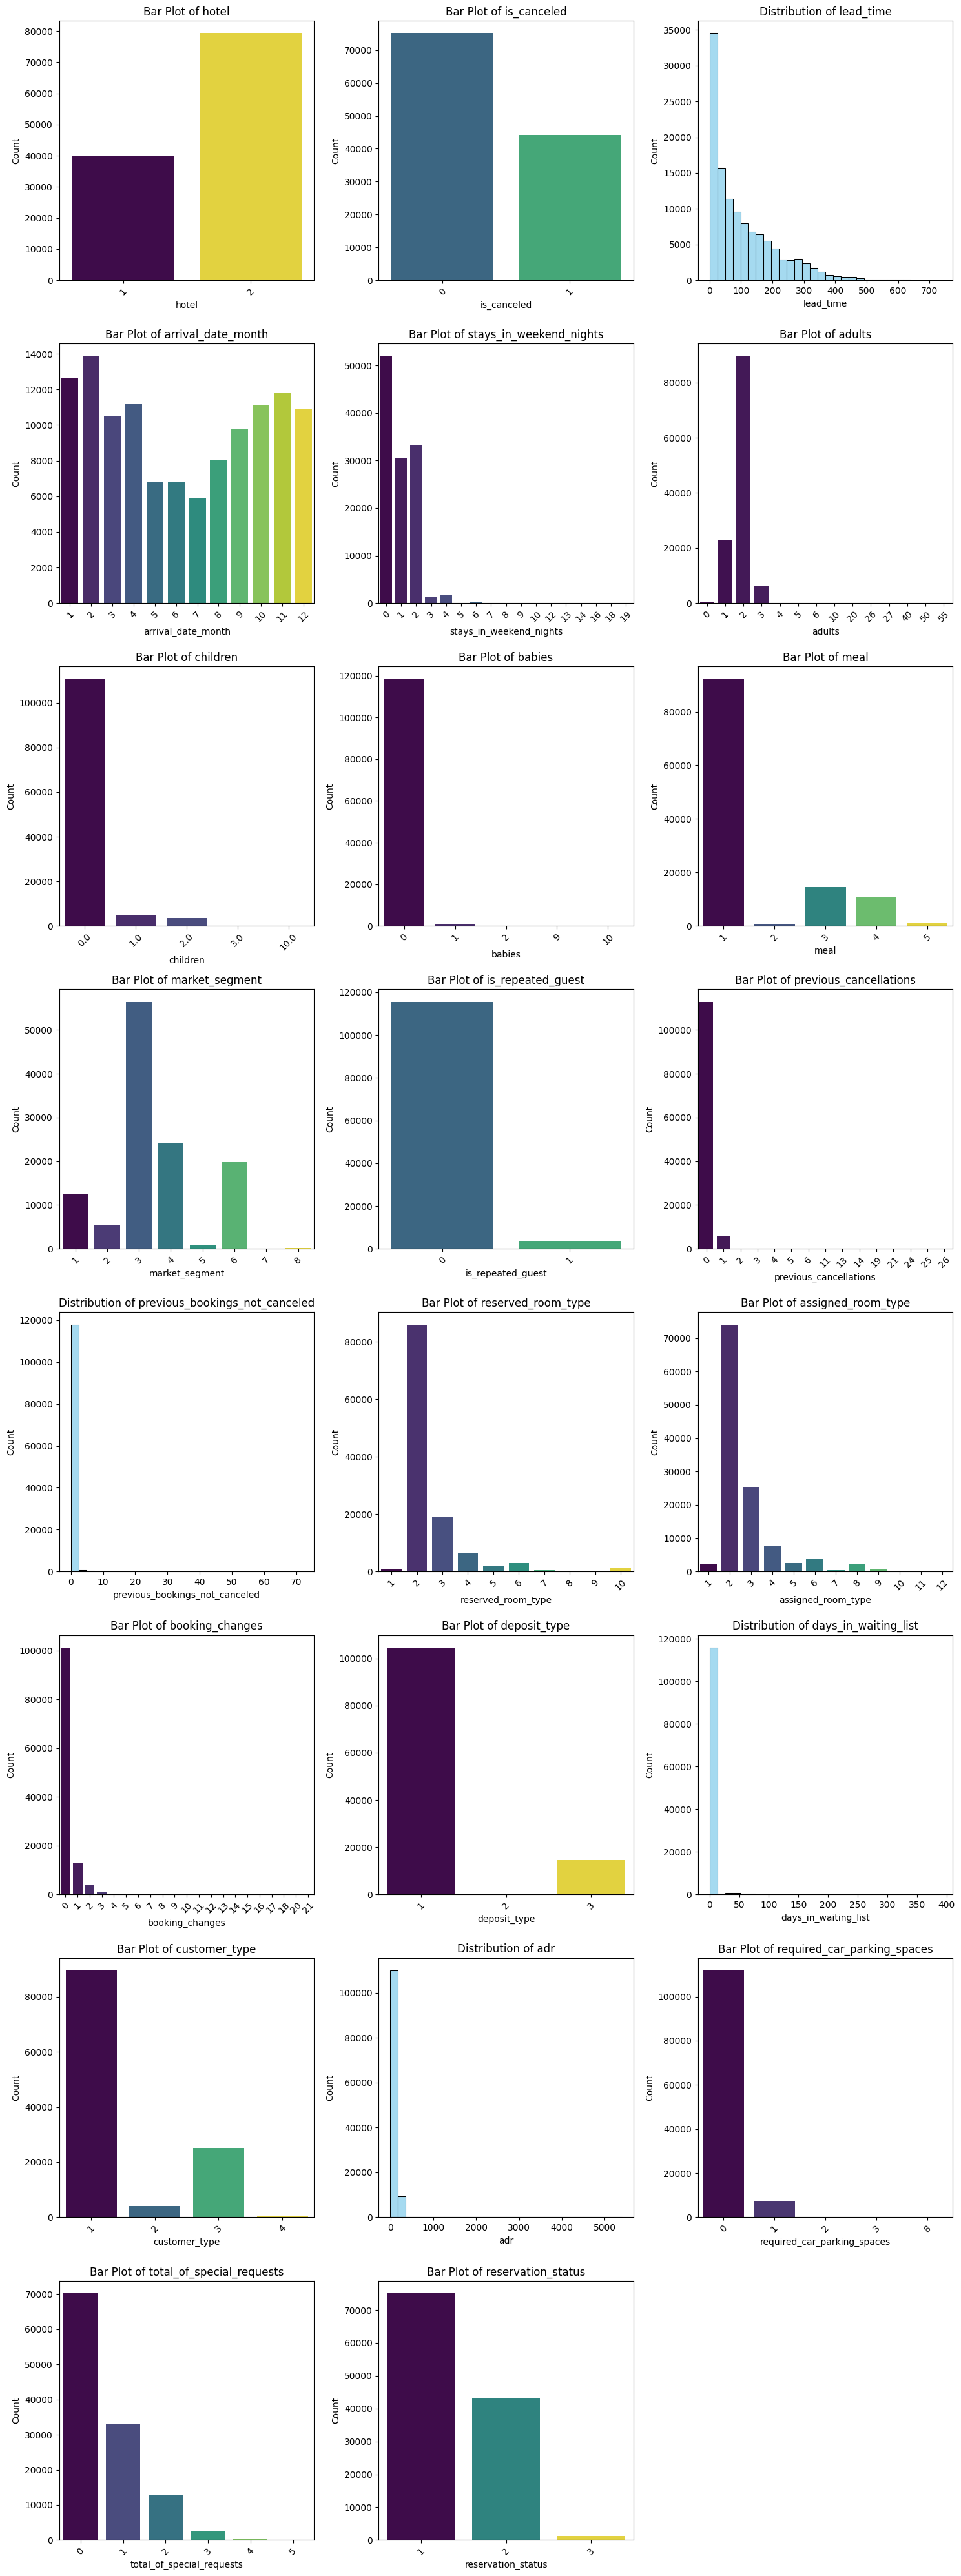

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Set up the figure size and layout
columns = hotels_subset.columns
n_cols = 3
n_rows = math.ceil(len(columns) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1)

    # If low cardinality (categorical/discrete), use a Bar Plot (Countplot)
    if hotels_subset[col].nunique() <= 50:
        # Using hue=col to avoid future warnings with palette
        sns.countplot(data=hotels_subset, x=col, palette='viridis', hue=col, legend=False)
        plt.title(f'Bar Plot of {col}')
        plt.xticks(rotation=45)
    # If high cardinality (continuous/many values), use a Histogram
    else:
        sns.histplot(data=hotels_subset, x=col, bins=30, color='skyblue')
        plt.title(f'Distribution of {col}')

    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Bivariate Analysis

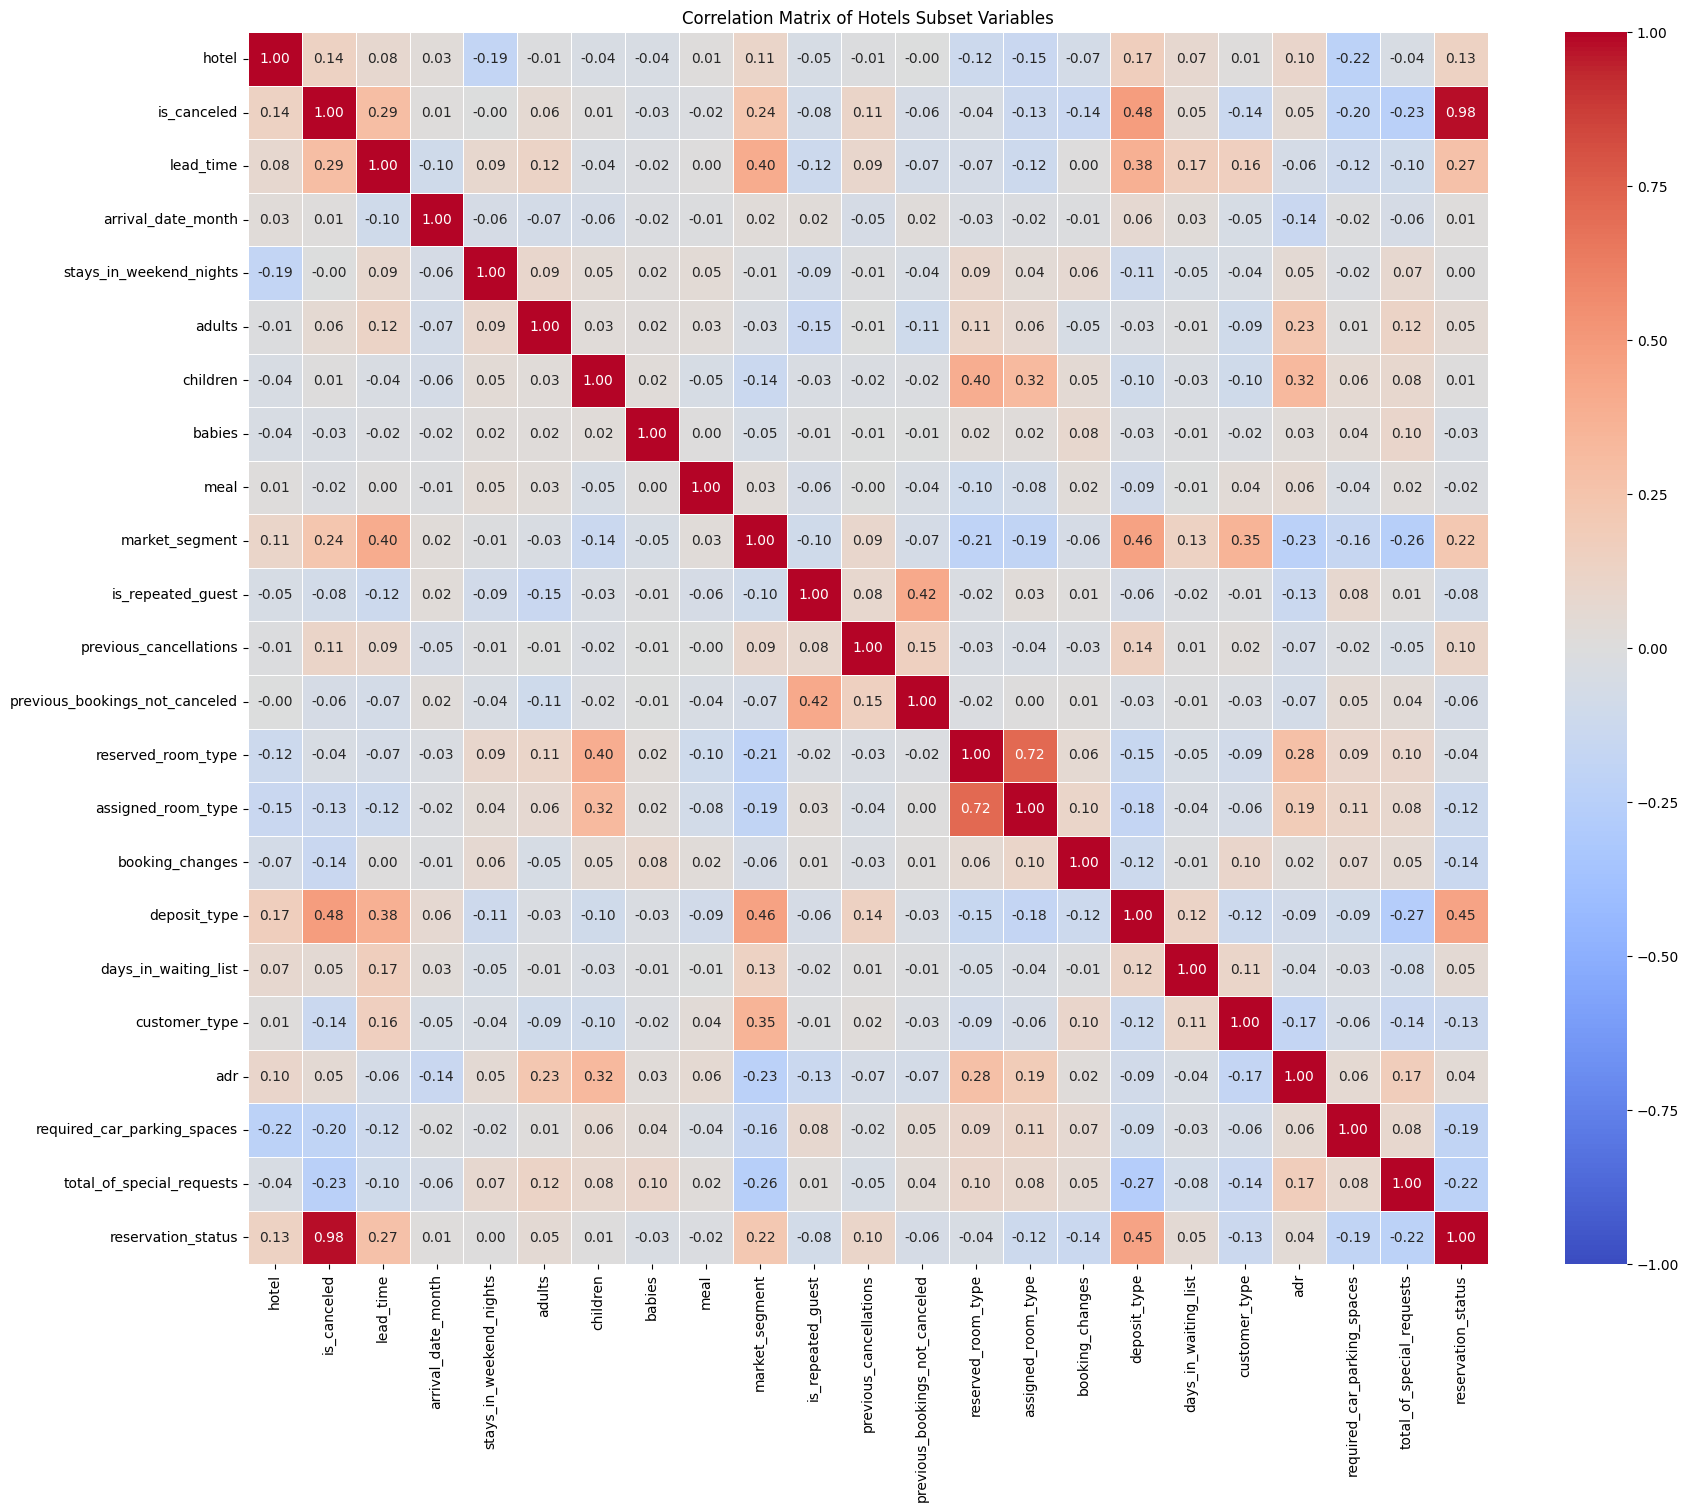

In [ ]:
plt.figure(figsize=(20, 16))

# Calculate the correlation matrix
correlation_matrix = hotels_subset.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Hotels Subset Variables')
plt.show()

## Multivariate Analysis

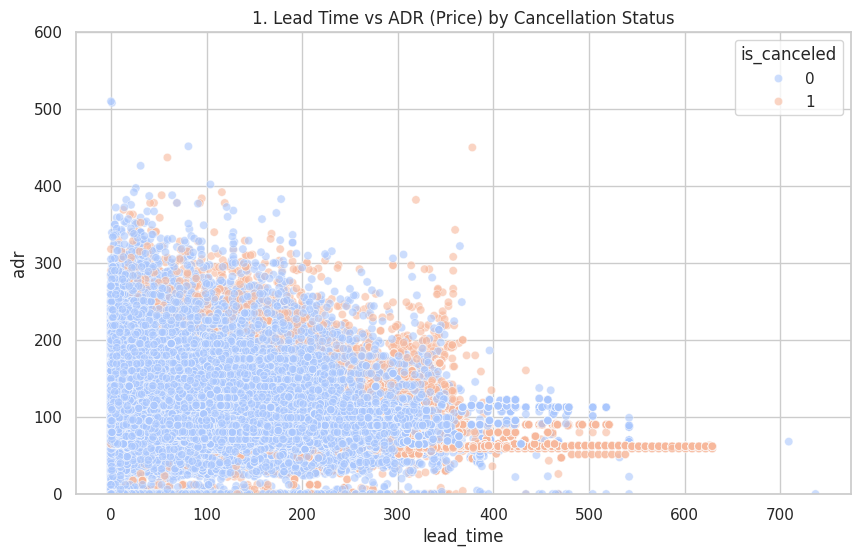

/tmp/ipython-input-2035429288.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hotels, x='is_canceled', y='lead_time', palette='Set2')


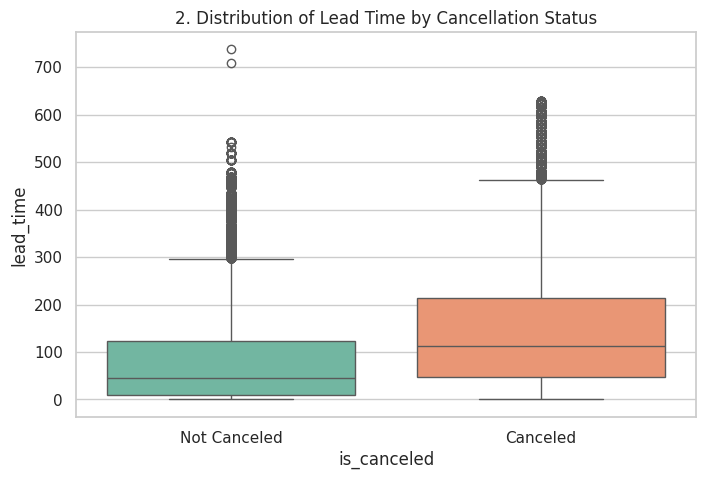

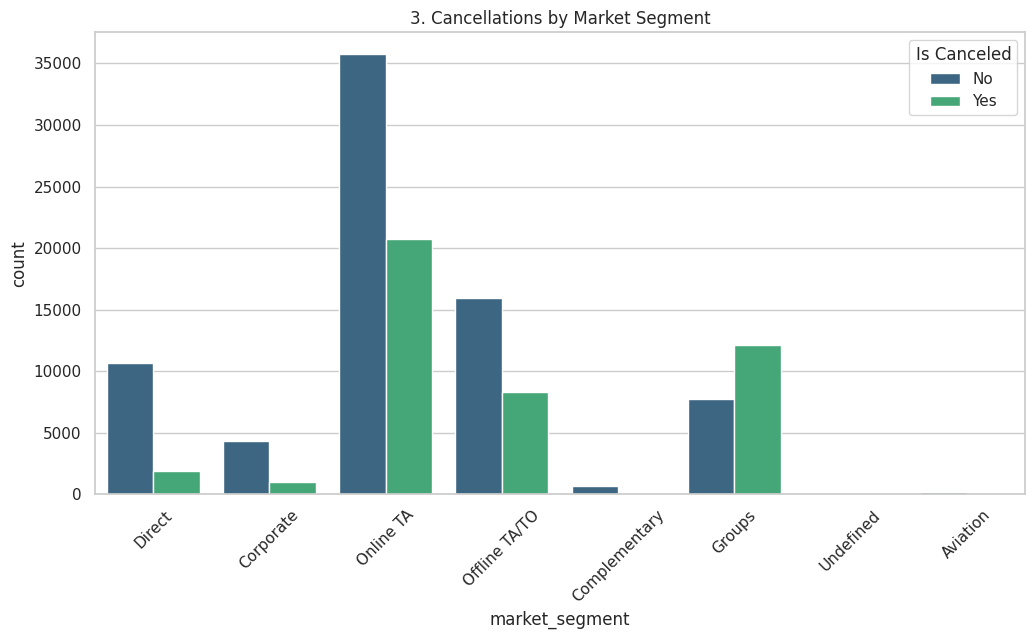

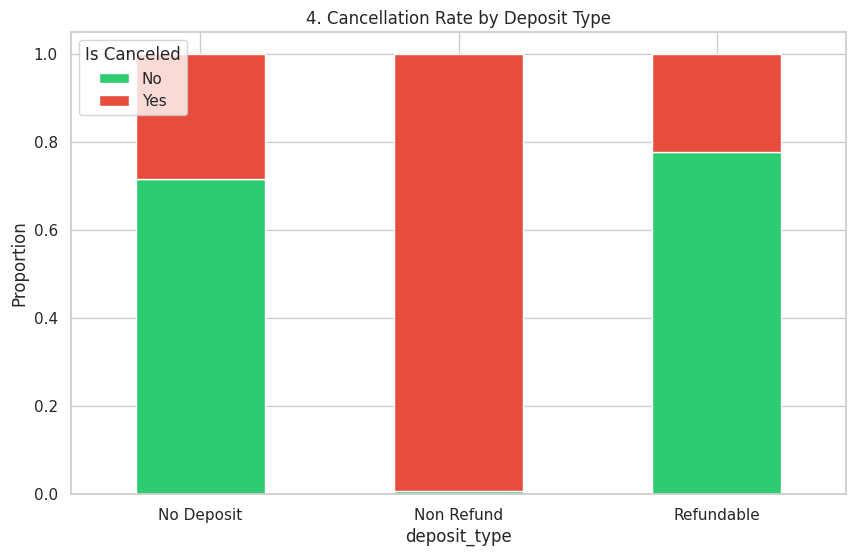

/tmp/ipython-input-2035429288.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hotels, x='total_of_special_requests', y='is_canceled', palette='magma', errorbar=None)


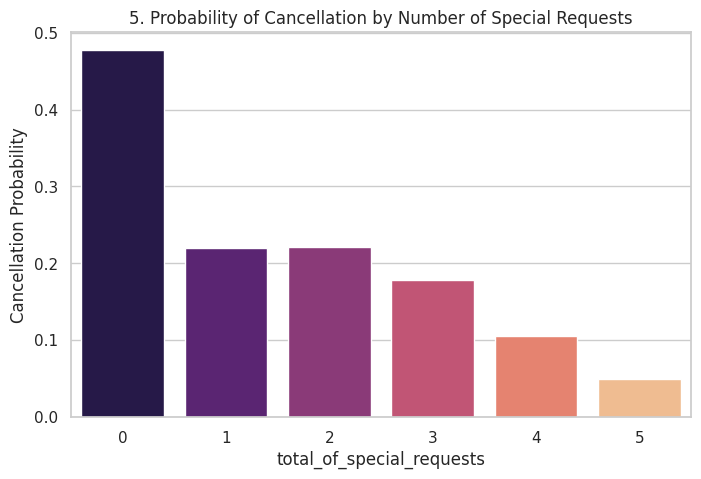

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_theme(style="whitegrid")

# We use the original 'hotels' dataframe for plotting to get readable text labels
# instead of the numeric codes in 'hotels_subset'.

# 1. Scatterplot: Lead Time vs ADR (Price) colored by Cancellation
# Business Question: Do expensive bookings made far in advance cancel more?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=hotels, x='lead_time', y='adr', hue='is_canceled', alpha=0.6, palette='coolwarm')
plt.title('1. Lead Time vs ADR (Price) by Cancellation Status')
plt.ylim(0, 600) # Limit y-axis to remove extreme outliers for better visibility
plt.show()

# 2. Boxplot: Lead Time vs Cancellation Status
# Business Question: Do canceled bookings have significantly longer lead times?
plt.figure(figsize=(8, 5))
sns.boxplot(data=hotels, x='is_canceled', y='lead_time', palette='Set2')
plt.title('2. Distribution of Lead Time by Cancellation Status')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.show()

# 3. Countplot: Market Segment vs Cancellation
# Business Question: Which market segments have the highest number of cancellations?
plt.figure(figsize=(12, 6))
sns.countplot(data=hotels, x='market_segment', hue='is_canceled', palette='viridis')
plt.title('3. Cancellations by Market Segment')
plt.xticks(rotation=45)
plt.legend(title='Is Canceled', labels=['No', 'Yes'])
plt.show()

# 4. Stacked Bar Plot: Deposit Type vs Cancellation Rate
# Business Question: Does a Non-Refundable deposit actually prevent cancellations?
# We create a crosstab to normalize the data (percentage)
deposit_cancellation = pd.crosstab(hotels['deposit_type'], hotels['is_canceled'], normalize='index')
deposit_cancellation.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#2ecc71', '#e74c3c'])
plt.title('4. Cancellation Rate by Deposit Type')
plt.ylabel('Proportion')
plt.legend(title='Is Canceled', labels=['No', 'Yes'], loc='upper left')
plt.xticks(rotation=0)
plt.show()

# 5. Bar Plot: Total Special Requests vs Cancellation Rate
# Business Question: Are customers who engage more (make requests) less likely to cancel?
plt.figure(figsize=(8, 5))
sns.barplot(data=hotels, x='total_of_special_requests', y='is_canceled', palette='magma', errorbar=None)
plt.title('5. Probability of Cancellation by Number of Special Requests')
plt.ylabel('Cancellation Probability')
plt.show()

## Setting target value

In [ ]:
# Define the target column (correcting spelling if necessary)
target_col = 'is_canceled'

# Separate features (X) and target (y)
X = hotels_subset.drop(columns=[target_col])
y = hotels_subset[target_col]

print(f"Target variable set to: {target_col}")
print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")

# Display the first few rows of X and y
print("\nFirst 5 rows of Features (X):")
display(X.head())
print("\nFirst 5 values of Target (y):")
display(y.head())

Target variable set to: is_canceled
Features shape (X): (119390, 22)
Target shape (y): (119390,)

First 5 rows of Features (X):


,hotel,lead_time,arrival_date_month,stays_in_weekend_nights,adults,children,babies,meal,market_segment,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
0,1,342,1,0,2,0.0,0,1,1,0,0,0,1,1,3,1,0,1,0.0,0,0,1
1,1,737,1,0,2,0.0,0,1,1,0,0,0,1,1,4,1,0,1,0.0,0,0,1
2,1,7,1,0,1,0.0,0,1,1,0,0,0,2,1,0,1,0,1,75.0,0,0,1
3,1,13,1,0,1,0.0,0,1,2,0,0,0,2,2,0,1,0,1,75.0,0,0,1
4,1,14,1,0,2,0.0,0,1,3,0,0,0,2,2,0,1,0,1,98.0,0,1,1



First 5 values of Target (y):


,is_canceled
0,0
1,0
2,0
3,0
4,0


In [ ]:
# Check for missing values in the current subset dataframe
missing_counts = hotels_subset.isnull().sum()
missing_data = missing_counts[missing_counts > 0]

if not missing_data.empty:
    print("Columns with missing values in hotels_subset:")
    display(missing_data)
else:
    print("No missing values found in hotels_subset.")

No missing values found in hotels_subset.


In [ ]:
# Fill missing values in 'children' with 0
hotels_subset['children'] = hotels_subset['children'].fillna(0)

# Verify the operation
print(f"Missing values in 'children' after filling: {hotels_subset['children'].isnull().sum()}")

Missing values in 'children' after filling: 0


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectFromModel
import pandas as pd
import numpy as np

# 1. Prepare Data
# Ensure we drop target and leakage column 'reservation_status'
X_fs = hotels_subset.drop(columns=['is_canceled', 'reservation_status'])
y_fs = hotels_subset['is_canceled']

# 2. SelectKBest (Filter Method - Chi-Square)
# Chi-square requires non-negative values, so we use MinMaxScaler
X_minmax = MinMaxScaler().fit_transform(X_fs)
selector_chi2 = SelectKBest(chi2, k=10)
selector_chi2.fit(X_minmax, y_fs)

# Get columns
cols_chi2 = X_fs.columns[selector_chi2.get_support()]
print("Top 10 Features (SelectKBest - Chi-Square):")
print(list(cols_chi2))
print("-" * 50)

# 3. Lasso Logistic Regression (Embedded Method - L1)
# Lasso requires standardized features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_fs)

lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
lasso.fit(X_scaled, y_fs)

# Select features with non-zero coefficients
model_lasso = SelectFromModel(lasso, prefit=True)
cols_lasso = X_fs.columns[model_lasso.get_support()]

# Sort by absolute coefficient value to find 'most important' among selected
coefs = pd.Series(np.abs(lasso.coef_[0]), index=X_fs.columns)
print("Top 10 Features (Lasso Logistic Regression - L1 Weight):")
print(list(coefs.sort_values(ascending=False).head(10).index))
print("-" * 50)

# 4. Tree-based Feature Importance (Embedded Method - Random Forest)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_fs, y_fs)

importances = pd.Series(rf.feature_importances_, index=X_fs.columns)
print("Top 10 Features (Random Forest Importance):")
print(list(importances.sort_values(ascending=False).head(10).index))

Top 10 Features (SelectKBest - Chi-Square):
['hotel', 'lead_time', 'market_segment', 'is_repeated_guest', 'previous_cancellations', 'booking_changes', 'deposit_type', 'customer_type', 'required_car_parking_spaces', 'total_of_special_requests']
--------------------------------------------------
Top 10 Features (Lasso Logistic Regression - L1 Weight):
['required_car_parking_spaces', 'previous_cancellations', 'deposit_type', 'previous_bookings_not_canceled', 'customer_type', 'total_of_special_requests', 'assigned_room_type', 'lead_time', 'adr', 'reserved_room_type']
--------------------------------------------------
Top 10 Features (Random Forest Importance):
['lead_time', 'adr', 'deposit_type', 'arrival_date_month', 'total_of_special_requests', 'market_segment', 'previous_cancellations', 'stays_in_weekend_nights', 'customer_type', 'assigned_room_type']


## Regression

Evaluation Metrics (including R2) for Logistic Regression on different feature subsets:

================= Chi-Square (SelectKBest) =================
Accuracy:               0.7714
Misclassification Rate: 0.2286
Sensitivity (Recall):   0.4581
Specificity:            0.9599
Precision:              0.8730
Recall:                 0.4581
AUC:                    0.8179


================= Lasso (L1 Regularization) =================
Accuracy:               0.7853
Misclassification Rate: 0.2147
Sensitivity (Recall):   0.4985
Specificity:            0.9579
Precision:              0.8769
Recall:                 0.4985
AUC:                    0.8304


================= Random Forest Importance =================
Accuracy:               0.7716
Misclassification Rate: 0.2284
Sensitivity (Recall):   0.4606
Specificity:            0.9588
Precision:              0.8706
Recall:                 0.4606
AUC:                    0.8027




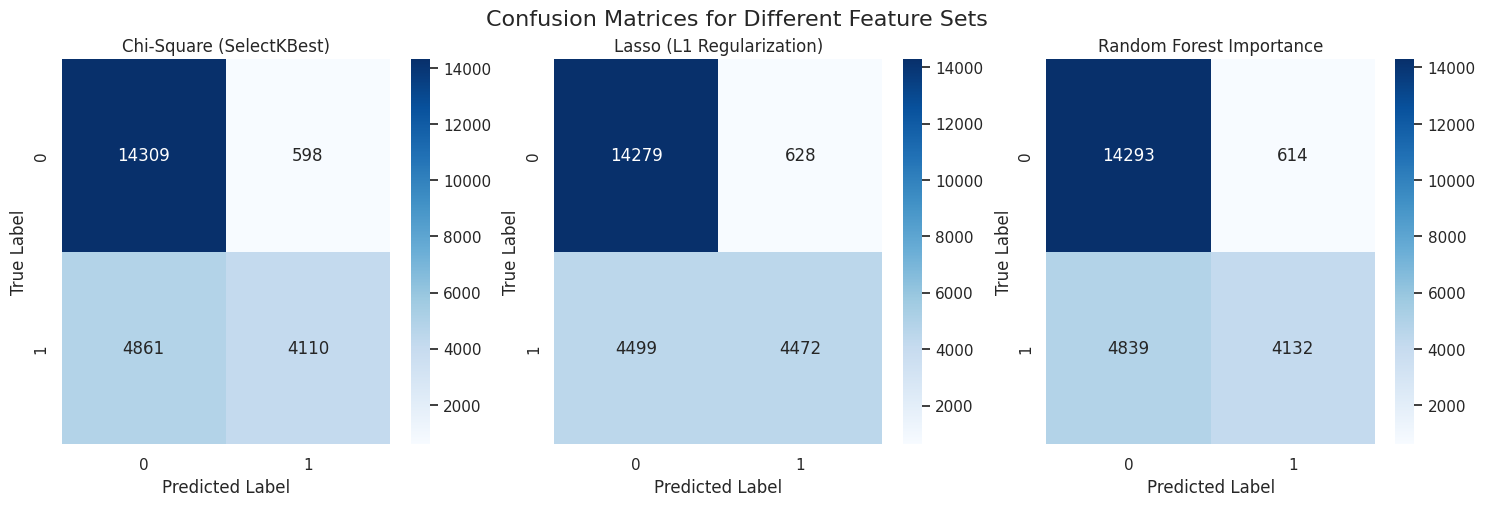

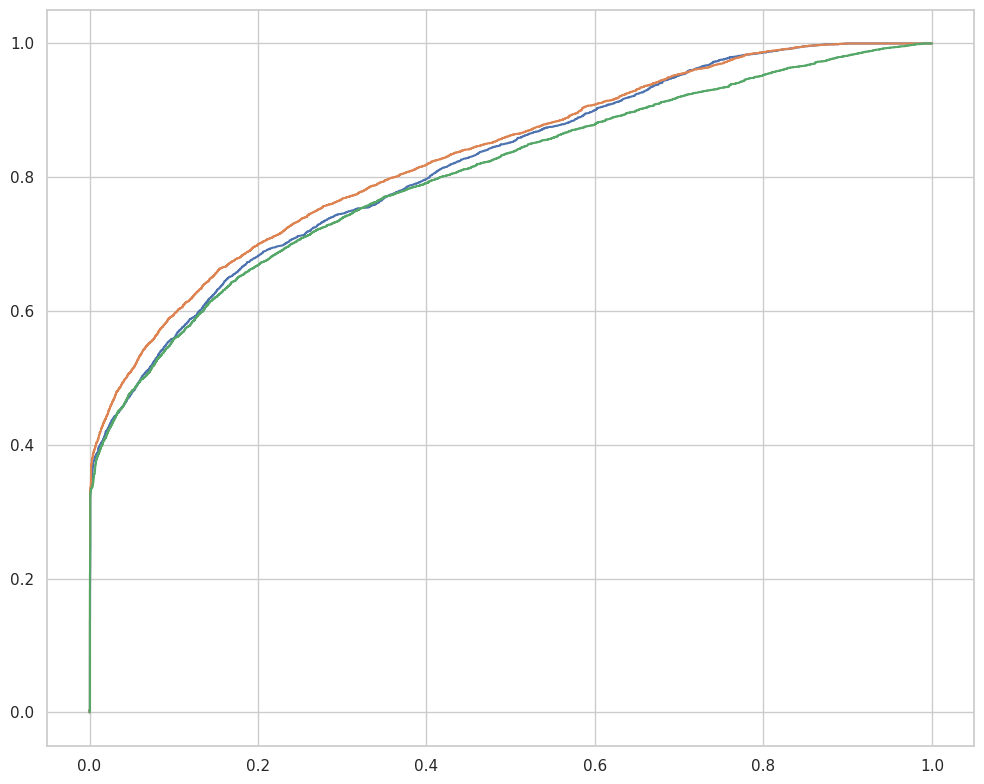

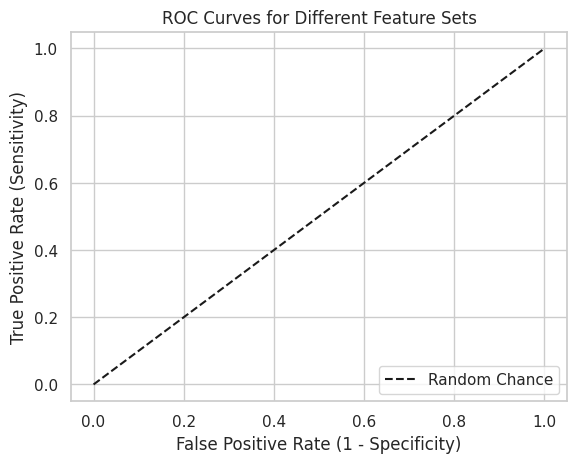

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, r2_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

# Define the feature sets based on previous selection results
# 1. Chi-Square Features
features_chi2 = list(cols_chi2)

# 2. Lasso Features (Top 10 by absolute coefficient weight)
features_lasso = list(coefs.sort_values(ascending=False).head(10).index)

# 3. Random Forest Features (Top 10 by importance)
features_rf = list(importances.sort_values(ascending=False).head(10).index)

feature_sets = {
    "Chi-Square (SelectKBest)": features_chi2,
    "Lasso (L1 Regularization)": features_lasso,
    "Random Forest Importance": features_rf
}

# Setup for plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices for Different Feature Sets', fontsize=16)

# Setup for ROC Plot
plt.figure(figsize=(10, 8))

print("Evaluation Metrics (including R2) for Logistic Regression on different feature subsets:\n")

for i, (name, features) in enumerate(feature_sets.items()):
    print(f"================= {name} =================")

    # Subset X to specific features
    X_subset = X[features]

    # Split data
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(X_subset, y, test_size=0.2, random_state=42)

    # Impute (fill missing with 0)
    imputer = SimpleImputer(strategy='constant', fill_value=0)
    X_train_imp = imputer.fit_transform(X_train_sub)
    X_test_imp = imputer.transform(X_test_sub)

    # Scale features
    scaler = StandardScaler()
    X_train_scl = scaler.fit_transform(X_train_imp)
    X_test_scl = scaler.transform(X_test_imp)

    # Train Logistic Regression
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_scl, y_train_sub)

    # Predict labels and probabilities
    y_pred = model.predict(X_test_scl)
    y_prob = model.predict_proba(X_test_scl)[:, 1]

    # Calculate Metrics
    accuracy = accuracy_score(y_test_sub, y_pred)
    misclassification_rate = 1 - accuracy
    precision = precision_score(y_test_sub, y_pred)
    recall = recall_score(y_test_sub, y_pred)
    r2 = r2_score(y_test_sub, y_pred)  # R2 Score as requested

    # Confusion Matrix details
    tn, fp, fn, tp = confusion_matrix(y_test_sub, y_pred).ravel()
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)

    # ROC & AUC
    fpr, tpr, _ = roc_curve(y_test_sub, y_prob)
    roc_auc = auc(fpr, tpr)

    # Print Metrics
    print(f"Accuracy:               {accuracy:.4f}")
    print(f"Misclassification Rate: {misclassification_rate:.4f}")
    print(f"Sensitivity (Recall):   {sensitivity:.4f}")
    print(f"Specificity:            {specificity:.4f}")
    print(f"Precision:              {precision:.4f}")
    print(f"Recall:                 {recall:.4f}")
    print(f"AUC:                    {roc_auc:.4f}")
    print("\n")

    # Plot ROC Curve (accumulate on one plot)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    # Plot Confusion Matrix (on subplot)
    cm = confusion_matrix(y_test_sub, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

# Show Confusion Matrices
plt.tight_layout()
plt.show()

# Finalize and Show ROC Plot
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves for Different Feature Sets')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Decision Tree Classifier

Running Decision Tree Baselines on 5 feature sets...

========== Chi-Square (10 features) ==========
Accuracy:               0.8228
Misclassification Rate: 0.1772
Sensitivity (Recall):   0.7084
Specificity:            0.8917
Precision:              0.7974
Recall:                 0.7084
AUC:                    0.8731


========== Lasso (10 features) ==========
Accuracy:               0.8112
Misclassification Rate: 0.1888
Sensitivity (Recall):   0.7392
Specificity:            0.8546
Precision:              0.7537
Recall:                 0.7392
AUC:                    0.8077


========== Random Forest (10 features) ==========
Accuracy:               0.8129
Misclassification Rate: 0.1871
Sensitivity (Recall):   0.7555
Specificity:            0.8474
Precision:              0.7487
Recall:                 0.7555
AUC:                    0.8061


========== Combined (Union) (16 features) ==========
Accuracy:               0.8229
Misclassification Rate: 0.1771
Sensitivity (Recall):   0.7724
Spec

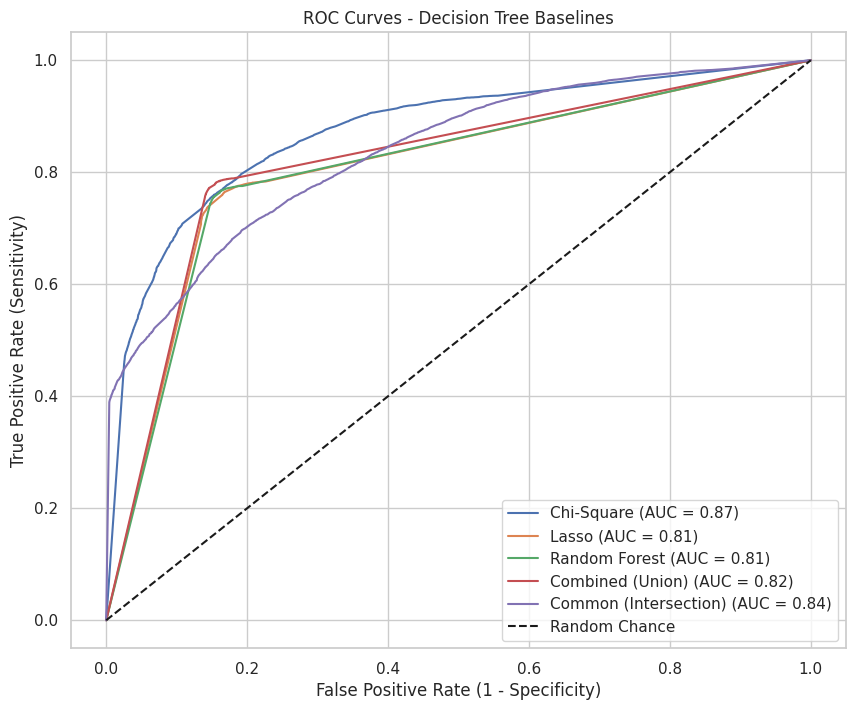

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_curve, auc,
    precision_score, recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Re-define the feature sets ensuring we have the lists
features_chi2 = list(cols_chi2)
features_lasso = list(coefs.sort_values(ascending=False).head(10).index)
features_rf = list(importances.sort_values(ascending=False).head(10).index)

# Union of all features
features_union = list(set(features_chi2 + features_lasso + features_rf))

# Intersection of all features (Common to all 3)
features_common = list(set(features_chi2) & set(features_lasso) & set(features_rf))

# Define the dictionary of feature sets to test
feature_sets_dt = {
    "Chi-Square": features_chi2,
    "Lasso": features_lasso,
    "Random Forest": features_rf,
    "Combined (Union)": features_union,
    "Common (Intersection)": features_common if features_common else []
}

# Remove empty sets if any (e.g. if intersection is empty)
feature_sets_dt = {k: v for k, v in feature_sets_dt.items() if len(v) > 0}

print(f"Running Decision Tree Baselines on {len(feature_sets_dt)} feature sets...\n")

# Setup for ROC Plot
plt.figure(figsize=(10, 8))

for name, features in feature_sets_dt.items():
    print(f"========== {name} ({len(features)} features) ==========")
    # print(f"Features: {features}")

    # Subset X
    X_dt = X[features]

    # Split data
    X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y, test_size=0.2, random_state=42)

    # Impute
    imputer = SimpleImputer(strategy='constant', fill_value=0)
    X_train_dt_imp = imputer.fit_transform(X_train_dt)
    X_test_dt_imp = imputer.transform(X_test_dt)

    # Train Decision Tree
    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train_dt_imp, y_train_dt)

    # Predict
    y_pred_dt = dt_model.predict(X_test_dt_imp)
    y_prob_dt = dt_model.predict_proba(X_test_dt_imp)[:, 1]

    # Evaluation
    accuracy = accuracy_score(y_test_dt, y_pred_dt)
    misclassification_rate = 1 - accuracy
    precision = precision_score(y_test_dt, y_pred_dt)
    recall = recall_score(y_test_dt, y_pred_dt)

    tn, fp, fn, tp = confusion_matrix(y_test_dt, y_pred_dt).ravel()
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)

    fpr, tpr, _ = roc_curve(y_test_dt, y_prob_dt)
    roc_auc = auc(fpr, tpr)

    print(f"Accuracy:               {accuracy:.4f}")
    print(f"Misclassification Rate: {misclassification_rate:.4f}")
    print(f"Sensitivity (Recall):   {sensitivity:.4f}")
    print(f"Specificity:            {specificity:.4f}")
    print(f"Precision:              {precision:.4f}")
    print(f"Recall:                 {recall:.4f}")
    print(f"AUC:                    {roc_auc:.4f}")
    print("\n")

    # Add to ROC Plot
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Finalize ROC Plot
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves - Decision Tree Baselines')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Naive Bayes